# Notebook 5: Societal & Ethical Relevance, Limitations, and Final Report
## Healthcare Symptom Pattern Discovery — Task 5
**Objective:** Synthesise all results into a final report, discuss ethical
considerations, enumerate technical and clinical limitations of the unsupervised
approach, and propose future work directions.

**Input :** `task4_interpreted.csv` + `task4_clinical_summary.csv`  
**Output:** `task5_final_report.csv` (complete pipeline artefact)


In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings, textwrap
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print("Setup complete.")


Setup complete.


In [2]:
# ── Load data from Notebook 4 ────────────────────────────────────────────────
df       = pd.read_csv('..//Result_NB4/task4_interpreted.csv', index_col=0)
summary  = pd.read_csv('..//Result_NB4/task4_clinical_summary.csv')

print(f"Final dataset shape: {df.shape}")
print(f"Clusters: {df['hc_cluster'].nunique()}")
print()
print("Risk category counts:")
print(df['risk_category'].value_counts().to_string())


Final dataset shape: (4920, 167)
Clusters: 41

Risk category counts:
risk_category
General / Mixed Risk          960
Gastrointestinal Risk         840
Hepatic / Jaundice Risk       720
Respiratory Risk              600
Neurological Risk             480
Dermatological Risk           360
Febrile / Infectious Risk     360
Metabolic / Endocrine Risk    360
Musculoskeletal Risk          240


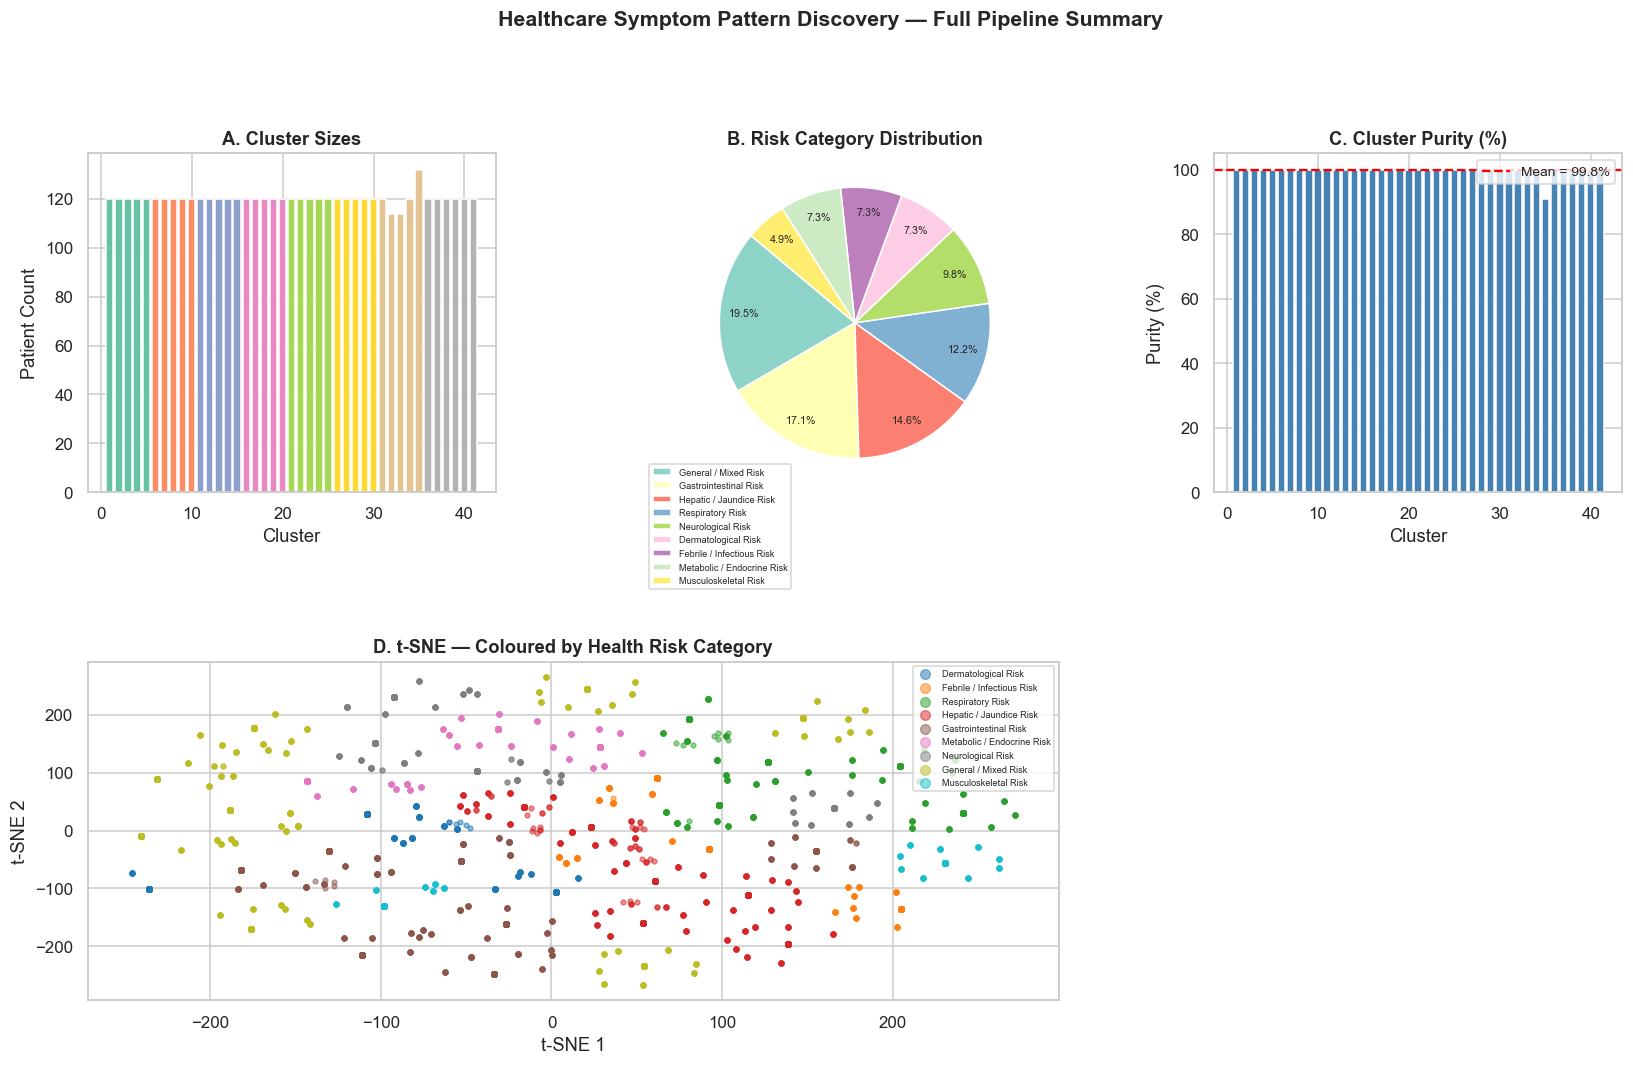

Saved → Result_NB5/task5_pipeline_summary.png


In [3]:
# ── Figure 1: Full Pipeline Summary Dashboard ─────────────────────────────────
# This single figure summarises all modelling outcomes in one view.
# Panel A: cluster sizes | B: risk distribution | C: cluster purity
# Panel D: t-SNE by risk category (visualising how well clusters separate health risk groups).

fig = plt.figure(figsize=(18, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

# A: Cluster sizes bar chart
ax_a = fig.add_subplot(gs[0, 0])
csizes = df['hc_cluster'].value_counts().sort_index()
colors_a = plt.cm.Set2(np.linspace(0, 1, len(csizes)))
ax_a.bar(csizes.index, csizes.values, color=colors_a, edgecolor='white')
ax_a.set_title('A. Cluster Sizes', fontweight='bold')
ax_a.set_xlabel('Cluster')
ax_a.set_ylabel('Patient Count')

# B: Risk category pie chart
ax_b = fig.add_subplot(gs[0, 1])
rcounts = df['risk_category'].value_counts()
colors_b = plt.cm.Set3(np.linspace(0, 1, len(rcounts)))
ax_b.pie(rcounts.values, colors=colors_b, autopct='%1.1f%%',
         startangle=140, pctdistance=0.82, textprops={'fontsize': 7})
ax_b.set_title('B. Risk Category Distribution', fontweight='bold')
ax_b.legend(rcounts.index, loc='lower left', fontsize=6,
            bbox_to_anchor=(-0.12, -0.3))

# C: Cluster purity bar chart
ax_c = fig.add_subplot(gs[0, 2])
ax_c.bar(summary['Cluster'], summary['Purity (%)'], color='steelblue', edgecolor='white')
ax_c.axhline(summary['Purity (%)'].mean(), color='red', linestyle='--',
             label=f"Mean = {summary['Purity (%)'].mean():.1f}%")
ax_c.set_title('C. Cluster Purity (%)', fontweight='bold')
ax_c.set_xlabel('Cluster')
ax_c.set_ylabel('Purity (%)')
ax_c.legend(fontsize=9)

# D: t-SNE coloured by risk category
ax_d = fig.add_subplot(gs[1, :2])
risk_cats   = df['risk_category'].unique()
risk_colors = plt.cm.tab10(np.linspace(0, 1, len(risk_cats)))
for i, rc in enumerate(risk_cats):
    mask = df['risk_category'] == rc
    ax_d.scatter(df.loc[mask, 'tsne_1'], df.loc[mask, 'tsne_2'],
                 c=[risk_colors[i]], s=10, alpha=0.5, label=rc)
ax_d.set_title('D. t-SNE — Coloured by Health Risk Category', fontweight='bold')
ax_d.set_xlabel('t-SNE 1')
ax_d.set_ylabel('t-SNE 2')
ax_d.legend(fontsize=6, markerscale=2, loc='upper right')


plt.suptitle('Healthcare Symptom Pattern Discovery — Full Pipeline Summary',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../Result_NB5/task5_pipeline_summary.png', bbox_inches='tight')
plt.show()
print("Saved → Result_NB5/task5_pipeline_summary.png")


In [4]:
# ── Ethical Considerations ───────────────────────────────────────────────────
# Structured documentation of ethical issues associated with deploying
# unsupervised learning in a healthcare context.

ethical_issues = {
    'Algorithmic Bias': (
        'The training dataset may over-represent certain demographics (e.g., specific '
        'geographies or age groups). Clusters discovered on such data may not generalise '
        'to populations absent from the dataset, leading to inequitable risk assessments '
        'for underrepresented groups.'
    ),
    'Label-Free Uncertainty': (
        'Clusters are inferred without ground-truth clinical diagnoses. A cluster labelled '
        '"Hepatic Risk" is a model inference, not a medical diagnosis. Treating output '
        'labels as clinical facts could lead to harmful care decisions.'
    ),
    'Data Privacy & Compliance': (
        'Patient symptom records are sensitive personal health information. Deployments '
        'must comply with HIPAA (USA), GDPR (EU), or equivalent national regulations. '
        'Re-identification through rare symptom combinations is a genuine risk even after '
        'direct identifiers are removed.'
    ),
    'Informed Consent': (
        'Patients whose records contributed to the dataset should have given explicit '
        'consent for research use. Provenance and consent status of public Kaggle datasets '
        'are often unclear or undocumented.'
    ),
    'Clinical Autonomy': (
        'Algorithmic tools must support clinician judgment, not replace it. Systematic '
        'over-reliance on model outputs can erode physician autonomy and reduce the quality '
        'of personalised patient care.'
    ),
    'Transparency & Explainability': (
        'While Ward clustering and GMM are relatively interpretable, the preceding PCA '
        'step reduces feature-level explainability. Clinicians need clear, symptom-level '
        'explanations of why a patient is assigned to a high-risk cluster.'
    ),
    'Equity in Benefit': (
        'Commercial deployment of risk-stratification tools must not exclude low-resource '
        'healthcare settings that arguably stand to benefit the most from early risk signals.'
    ),
}

print("=" * 72)
print("  ETHICAL CONSIDERATIONS IN UNSUPERVISED HEALTHCARE ANALYSIS")
print("=" * 72)
for issue, desc in ethical_issues.items():
    print(f"\n  ▶ {issue}")
    for line in textwrap.wrap(desc, width=70):
        print(f"    {line}")


  ETHICAL CONSIDERATIONS IN UNSUPERVISED HEALTHCARE ANALYSIS

  ▶ Algorithmic Bias
    The training dataset may over-represent certain demographics (e.g.,
    specific geographies or age groups). Clusters discovered on such data
    may not generalise to populations absent from the dataset, leading to
    inequitable risk assessments for underrepresented groups.

  ▶ Label-Free Uncertainty
    Clusters are inferred without ground-truth clinical diagnoses. A
    cluster labelled "Hepatic Risk" is a model inference, not a medical
    diagnosis. Treating output labels as clinical facts could lead to
    harmful care decisions.

  ▶ Data Privacy & Compliance
    Patient symptom records are sensitive personal health information.
    Deployments must comply with HIPAA (USA), GDPR (EU), or equivalent
    national regulations. Re-identification through rare symptom
    combinations is a genuine risk even after direct identifiers are
    removed.

  ▶ Informed Consent
    Patients whose records

In [5]:
# ── Technical & Clinical Limitations ─────────────────────────────────────────
limitations = {
    'No Temporal Information': (
        'The dataset captures a static snapshot of symptoms. Temporal evolution of '
        'symptoms — often critical for differential diagnosis — is completely absent.'
    ),
    'Symptom Subjectivity': (
        'Symptoms such as "fatigue" or "malaise" are self-reported and highly variable '
        'across individuals and reporters. This introduces measurement noise that '
        'unsupervised models cannot resolve.'
    ),
    'Missing Clinical Context': (
        'Laboratory values, vital signs, imaging findings, and comorbidities are absent. '
        'Symptom patterns alone are insufficient for reliable clinical risk stratification.'
    ),
    'Cluster Instability': (
        'Hierarchical clustering is sensitive to outliers and linkage choice. Minor '
        'perturbations in the dataset can shift cluster boundaries non-trivially.'
    ),
    'Optimal k Ambiguity': (
        'Silhouette score guides but does not uniquely determine the best k. '
        'Different internal indices can disagree, and the medically "correct" number '
        'of clusters requires domain expert input.'
    ),
    'Binary Encoding Limitations': (
        'Binary presence/absence encoding ignores symptom severity, duration, and '
        'frequency. Two patients with very different illness burdens appear identical '
        'if they share the same symptom set.'
    ),
    'Validation Gap': (
        'Without prospective clinical validation on real patient cohorts, the health-risk '
        'groupings remain working hypotheses. ARI against known labels is a proxy metric, '
        'not a clinical proof of utility.'
    ),
    'Dimensionality vs Explainability': (
        'PCA sacrifices per-feature interpretability for computational efficiency. This '
        'trade-off makes it harder to present individual symptom contributions to '
        'clinicians in a transparent and trustworthy manner.'
    ),
    'Dataset Size Constraints': (
        'With 4920 records and 41 disease classes, the dataset is small by machine-learning '
        'standards. Deep clustering or transformer-based models would require far larger '
        'and more diverse symptom corpora.'
    ),
}

print("=" * 72)
print("  TECHNICAL AND CLINICAL LIMITATIONS")
print("=" * 72)
for lim, desc in limitations.items():
    print(f"\n  ▶ {lim}")
    for line in textwrap.wrap(desc, width=70):
        print(f"    {line}")


  TECHNICAL AND CLINICAL LIMITATIONS

  ▶ No Temporal Information
    The dataset captures a static snapshot of symptoms. Temporal evolution
    of symptoms — often critical for differential diagnosis — is
    completely absent.

  ▶ Symptom Subjectivity
    Symptoms such as "fatigue" or "malaise" are self-reported and highly
    variable across individuals and reporters. This introduces measurement
    noise that unsupervised models cannot resolve.

  ▶ Missing Clinical Context
    Laboratory values, vital signs, imaging findings, and comorbidities
    are absent. Symptom patterns alone are insufficient for reliable
    clinical risk stratification.

  ▶ Cluster Instability
    Hierarchical clustering is sensitive to outliers and linkage choice.
    Minor perturbations in the dataset can shift cluster boundaries non-
    trivially.

  ▶ Optimal k Ambiguity
    Silhouette score guides but does not uniquely determine the best k.
    Different internal indices can disagree, and the medic

In [6]:
# ── Societal Benefits ─────────────────────────────────────────────────────────
benefits = {
    'Early Risk Stratification': (
        'Clustering can flag high-risk patient profiles before formal diagnosis, enabling '
        'timely triage in resource-limited healthcare environments.'
    ),
    'Clinical Decision Support': (
        'Surfacing cluster context during consultations helps clinicians generate richer '
        'differential diagnoses and reduces diagnostic errors.'
    ),
    'Epidemiological Surveillance': (
        'Monitoring cluster membership over time can detect early signals of emerging '
        'outbreaks or seasonal disease surges in population health dashboards.'
    ),
    'Healthcare Resource Allocation': (
        'Policymakers can allocate specialty resources (hepatology, pulmonology, etc.) '
        'proportionally based on the prevalence of risk clusters in regional data.'
    ),
    'Medical Education': (
        'Visualised symptom clusters provide clinically grounded, data-driven teaching '
        'materials for medical students learning multi-symptom disease recognition.'
    ),
}

print("=" * 72)
print("  SOCIETAL BENEFITS")
print("=" * 72)
for benefit, desc in benefits.items():
    print(f"\n  ▶ {benefit}")
    for line in textwrap.wrap(desc, width=70):
        print(f"    {line}")


  SOCIETAL BENEFITS

  ▶ Early Risk Stratification
    Clustering can flag high-risk patient profiles before formal
    diagnosis, enabling timely triage in resource-limited healthcare
    environments.

  ▶ Clinical Decision Support
    Surfacing cluster context during consultations helps clinicians
    generate richer differential diagnoses and reduces diagnostic errors.

  ▶ Epidemiological Surveillance
    Monitoring cluster membership over time can detect early signals of
    emerging outbreaks or seasonal disease surges in population health
    dashboards.

  ▶ Healthcare Resource Allocation
    Policymakers can allocate specialty resources (hepatology,
    pulmonology, etc.) proportionally based on the prevalence of risk
    clusters in regional data.

  ▶ Medical Education
    Visualised symptom clusters provide clinically grounded, data-driven
    teaching materials for medical students learning multi-symptom disease
    recognition.


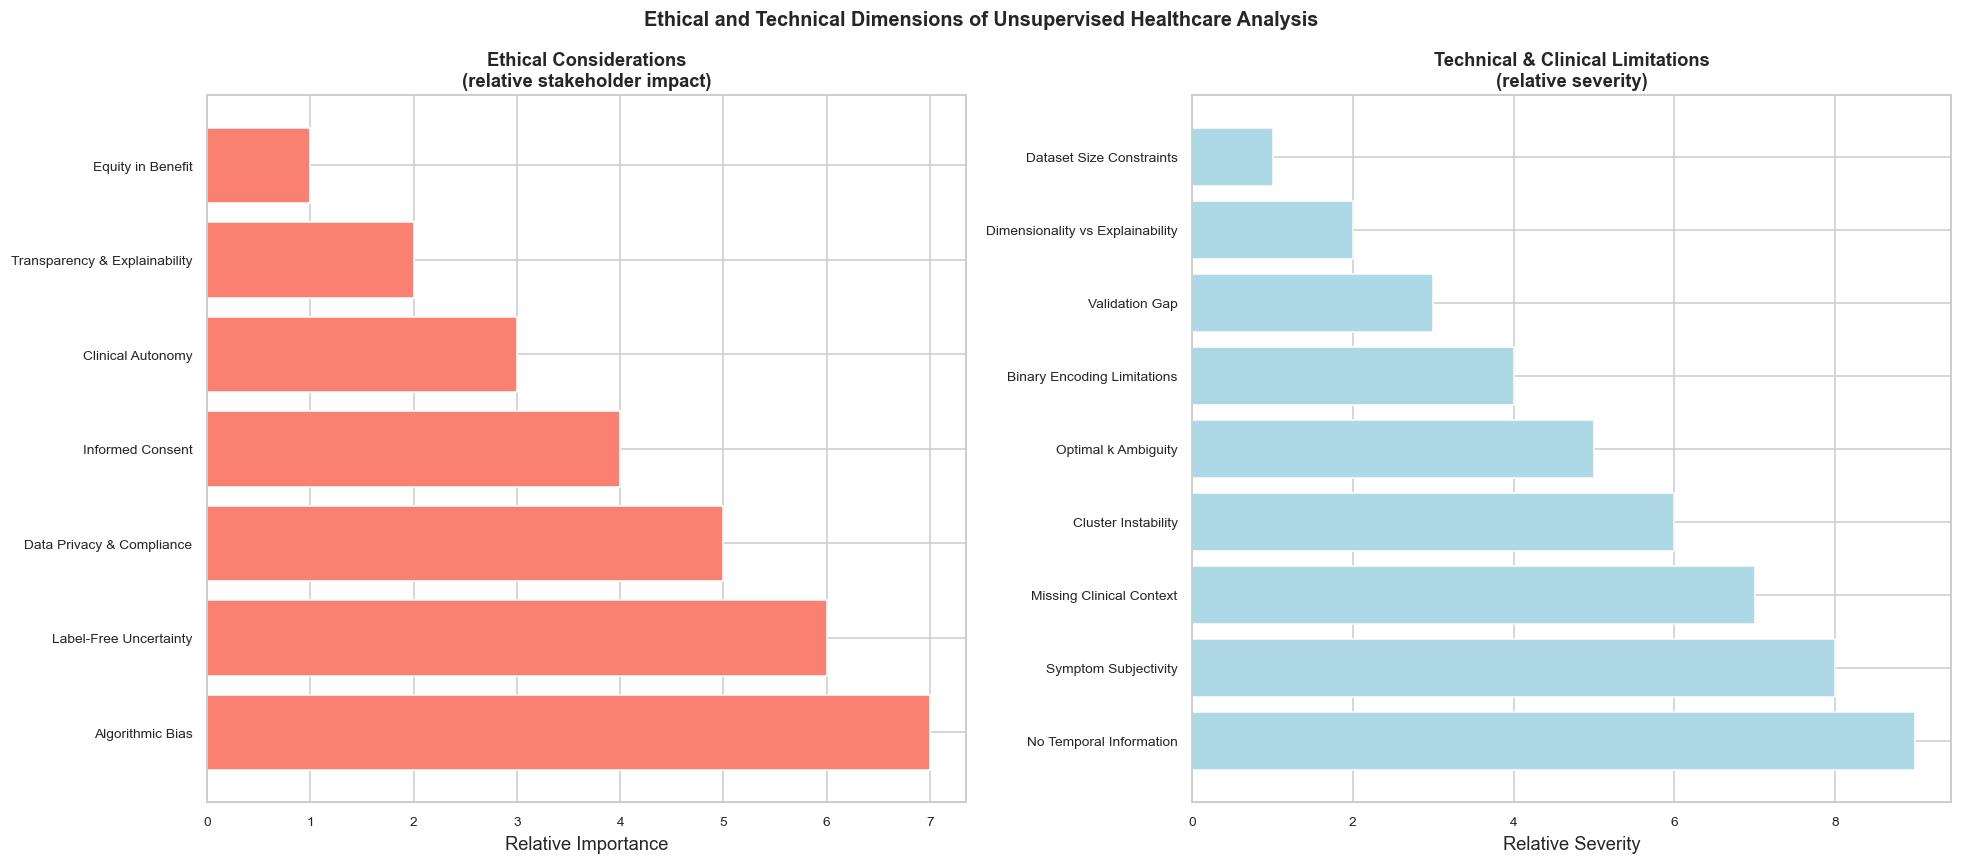

Saved → Result_NB5/task5_ethics_limitations.png


In [7]:
# ── Figure 2: Ethical & Limitation Importance Visual ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

eth_names = list(ethical_issues.keys())
axes[0].barh(eth_names, range(len(eth_names), 0, -1),
             color='salmon', edgecolor='white')
axes[0].set_title('Ethical Considerations\n(relative stakeholder impact)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Relative Importance')
axes[0].tick_params(labelsize=9)

lim_names = list(limitations.keys())
axes[1].barh(lim_names, range(len(lim_names), 0, -1),
             color='lightblue', edgecolor='white')
axes[1].set_title('Technical & Clinical Limitations\n(relative severity)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Relative Severity')
axes[1].tick_params(labelsize=9)

plt.suptitle('Ethical and Technical Dimensions of Unsupervised Healthcare Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('..//Result_NB5/task5_ethics_limitations.png', bbox_inches='tight')
plt.show()
print("Saved → Result_NB5/task5_ethics_limitations.png")


In [8]:
# ── Recommended Future Work ───────────────────────────────────────────────────
future_work = [
    "1. Incorporate lab results (CBC, LFT, RFT) as continuous features alongside binary symptoms.",
    "2. Apply UMAP for faster, topology-preserving dimensionality reduction instead of t-SNE.",
    "3. Use HDBSCAN to automatically detect noise patients with rare/mixed symptom profiles.",
    "4. Perform longitudinal clustering to track how patients transition between risk groups over time.",
    "5. Validate clusters with practising clinicians through a structured Delphi survey.",
    "6. Explore deep clustering (variational autoencoder + k-means) for richer latent representations.",
    "7. Integrate demographic features (age, sex, region) to detect population-level disparities.",
    "8. Develop a SHAP-based explainability layer on cluster centroids for clinical-facing interfaces.",
    "9. Test generalisability by training on one regional dataset and evaluating on another.",
    "10. Build a real-time risk-stratification API using the GMM soft-assignment probabilities.",
]

print("=" * 72)
print("  RECOMMENDED FUTURE WORK")
print("=" * 72)
for item in future_work:
    print(f"  {item}")


  RECOMMENDED FUTURE WORK
  1. Incorporate lab results (CBC, LFT, RFT) as continuous features alongside binary symptoms.
  2. Apply UMAP for faster, topology-preserving dimensionality reduction instead of t-SNE.
  3. Use HDBSCAN to automatically detect noise patients with rare/mixed symptom profiles.
  4. Perform longitudinal clustering to track how patients transition between risk groups over time.
  5. Validate clusters with practising clinicians through a structured Delphi survey.
  6. Explore deep clustering (variational autoencoder + k-means) for richer latent representations.
  7. Integrate demographic features (age, sex, region) to detect population-level disparities.
  8. Develop a SHAP-based explainability layer on cluster centroids for clinical-facing interfaces.
  9. Test generalisability by training on one regional dataset and evaluating on another.
  10. Build a real-time risk-stratification API using the GMM soft-assignment probabilities.


In [9]:
# ── Build and save the final consolidated report CSV ─────────────────────────
risk_desc = {
    'Hepatic / Jaundice Risk':    'Liver-related conditions — jaundice, dark urine, liver failure',
    'Respiratory Risk':           'Lung and airway conditions — cough, breathlessness, phlegm',
    'Gastrointestinal Risk':      'GI tract conditions — vomiting, diarrhoea, stomach pain',
    'Dermatological Risk':        'Skin conditions — rash, itching, eruptions, blisters',
    'Neurological Risk':          'Brain/nerve conditions — headache, dizziness, altered sensorium',
    'Metabolic / Endocrine Risk': 'Metabolic disorders — fatigue, weight change, polyuria',
    'Musculoskeletal Risk':       'Joint and muscle conditions — joint pain, stiffness',
    'Febrile / Infectious Risk':  'Infectious diseases — fever, chills, sweating, lymphadenopathy',
    'General / Mixed Risk':       'Mixed or non-specific symptom profiles',
}

final_df = summary.copy()
final_df['Risk Description']  = final_df['Risk Category'].map(
    lambda r: risk_desc.get(r, 'Mixed symptoms'))
final_df['Analysis Models']   = 'Hierarchical Clustering (Ward Linkage) + GMM (Full Covariance)'
final_df['Dataset']           = 'Disease Symptom Dataset (Kaggle) — 4920 patients, 130 symptoms, 41 diseases'
final_df['Encoding Method']   = 'Binary (1 = symptom present, 0 = absent) + 6 domain aggregate features'
final_df['Dim Reduction']     = 'PCA (80% variance retained)'
final_df['Cluster Validation']= 'Silhouette Score, Davies-Bouldin Index, Adjusted Rand Index'

output_path = '..//Result_NB5/task5_final_report.csv'
final_df.to_csv(output_path, index=False)

print("=== FINAL REPORT ===")
display(final_df[['Cluster','Size','Risk Category','Top 5 Symptoms','Dominant Disease','Purity (%)']])
print(f"\n✅ Saved: {output_path}")
print("\n🎉 All 5 Notebooks Complete — Full Pipeline Successfully Executed!")


=== FINAL REPORT ===


,Cluster,Size,Risk Category,Top 5 Symptoms,Dominant Disease,Purity (%)
0,1,120,Respiratory Risk,"pca_6, pca_7, pca_14, chest_pain, congestion",Common Cold,100.0
1,2,120,Neurological Risk,"pca_8, pca_6, abnormal_menstruation, brittle_n...",Hypothyroidism,100.0
2,3,120,Metabolic / Endocrine Risk,"pca_4, pca_7, pca_8, pca_12, pca_14",Hypoglycemia,100.0
3,4,120,Metabolic / Endocrine Risk,"pca_4, pca_5, pca_10, pca_11, pca_7",Diabetes,100.0
4,5,120,General / Mixed Risk,"pca_20, pca_16, pca_4, pca_15, pca_11",Hyperthyroidism,100.0
5,6,120,General / Mixed Risk,"pca_13, pca_4, pca_27, pca_22, pca_17",Migraine,100.0
6,7,120,Respiratory Risk,"pca_5, pca_24, pca_9, pca_21, pca_27",Tuberculosis,100.0
7,8,120,General / Mixed Risk,"pca_30, pca_9, pca_22, pca_29, pca_28",Pneumonia,100.0
8,9,120,Febrile / Infectious Risk,"pca_16, pca_10, pca_8, pca_22, pca_11",Typhoid,100.0
9,10,120,Neurological Risk,"pca_5, pca_7, pca_17, pca_24, pca_8",Chicken pox,100.0



✅ Saved: ..//Result_NB5/task5_final_report.csv

🎉 All 5 Notebooks Complete — Full Pipeline Successfully Executed!
